# Kalman Filters

The Kalman filter is a powerful, recursive mathematical algorithm used to estimate the true state of a dynamic system from a sequence of noisy, imperfect, or indirect measurements over time. It is especially useful when some important variables (states) are not directly observable, measurements contain random errors (noise), and the system itself evolves with some uncertainty.Developed by Rudolf E. Kálmán in the early 1960s, it became foundational in fields like aerospace, robotics, navigation, signal processing, and control theory. Under the assumptions of linearity and Gaussian noise, the Kalman filter is optimal — it provides the best possible estimate in the sense of minimizing the mean squared estimation error.

### Core Idea — Intuitive Explanation

Imagine you're trying to track the position and velocity of a car, drone, or satellite:You have a reasonably good physics-based model of how the object should move (e.g., constant velocity, acceleration due to thrust/gravity). But your sensors (GPS, radar, accelerometers) give noisy, delayed, or biased readings. The Kalman filter smartly blends:Your model's prediction of where the object should be now (based on previous best estimate + physics), with the new sensor measurement (which is noisy but provides fresh information).

It does this in a way that gives more weight to whichever source is more trustworthy at that moment:If the model is very reliable (low process uncertainty) → trust the prediction more. If the sensor is very accurate (low measurement noise) → trust the measurement more. The result is an estimate that is usually better (lower uncertainty) than using either the model or the measurements alone.

### How the Kalman Filter Works — The Predict–Update Cycle

The algorithm runs in a tight loop with **two main phases** at each time step:

**1. Prediction (Time Update / Propagate)**

Use the system's dynamic model to forecast:
- What the state should be at the next time step
- How much uncertainty (error covariance) grows due to model imperfections and random disturbances

*Mathematically (standard notation):*

**Predicted state:**
$$
\hat{\mathbf{x}}_{k|k-1} = \mathbf{F}_k \hat{\mathbf{x}}_{k-1|k-1} + \mathbf{B}_k \mathbf{u}_k
$$

**Predicted covariance (uncertainty):**
$$
\mathbf{P}_{k|k-1} = \mathbf{F}_k \mathbf{P}_{k-1|k-1} \mathbf{F}_k^T + \mathbf{Q}_k
$$

Where:
- $\mathbf{F}_k$ (or **A** in some notations) = state transition matrix (how state evolves)
- $\mathbf{B}_k$ = control input matrix
- $\mathbf{u}_k$ = known control inputs (e.g., acceleration command)
- $\mathbf{Q}_k$ = process noise covariance (model uncertainty)

**2. Update (Measurement Update / Correct)**

When a new measurement $\mathbf{z}_k$ arrives:
- Compute the **innovation** (residual): difference between actual measurement and what the prediction expected
- Compute the **Kalman gain** $\mathbf{K}_k$ — this is the key blending factor that decides how much to trust the new measurement vs. the prediction
- Update the state estimate and reduce uncertainty accordingly

*Key equations:*

**Innovation:**
$$
\tilde{\mathbf{y}}_k = \mathbf{z}_k - \mathbf{H}_k \hat{\mathbf{x}}_{k|k-1}
$$

**Kalman gain:**
$$
\mathbf{K}_k = \mathbf{P}_{k|k-1} \mathbf{H}_k^T \left( \mathbf{H}_k \mathbf{P}_{k|k-1} \mathbf{H}_k^T + \mathbf{R}_k \right)^{-1}
$$

**Updated state:**
$$
\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k \tilde{\mathbf{y}}_k
$$

**Updated covariance:**
$$
\mathbf{P}_{k|k} = \left( \mathbf{I} - \mathbf{K}_k \mathbf{H}_k \right) \mathbf{P}_{k|k-1}
$$

Where:
- $\mathbf{H}_k$ (observation matrix) = maps true state to expected measurement
- $\mathbf{R}_k$ = measurement noise covariance

This cycle repeats indefinitely:  **predict → measure → update → predict → ...**

**Key Components / Matrices**
- **State transition matrix** (A or F): Describes how the state evolves (e.g., position → position + velocity × Δt)
- **Observation/measurement matrix** (H): Tells what part of the state we actually measure (e.g., we measure position, but state includes position + velocity → H = [1 0])
- **Control matrix** (B) and inputs (u): For known external forces/controls
- **Process noise covariance** (Q): Uncertainty in the model itself
- **Measurement noise covariance** (R): How noisy/trustworthy the sensors are
- **Error covariance** (P): Tracks how uncertain our current state estimate is

In [16]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

from matplotlib import pyplot as plt
from pykalman import KalmanFilter

warnings.filterwarnings("ignore")

### Example Application: Estimating a Moving Average (or Rolling Parameters) with a Kalman Filter

Because the Kalman filter updates its state estimates at **every time step** and naturally places **greater weight on more recent observations** (while gradually discounting older ones), it is particularly well-suited for estimating **time-varying (rolling) parameters** in a dataset.

#### Key Advantages Over Traditional Moving Averages
- Unlike a simple n-day moving average, the Kalman filter does **not** require you to specify a fixed window length.
- The smoothing effect emerges naturally from the filter’s recursive update mechanism and the assumed dynamics of the underlying state.
- This makes it especially useful for:
  - Computing smoothed rolling averages
  - Estimating rolling Sharpe ratios
  - Tracking slowly changing regression coefficients, volatilities, correlations, or other time-varying quantities

#### How We Model the Problem in This Example

We want to estimate the **rolling mean** of a time series (or any slowly evolving parameter).

**State model assumptions (random walk with small noise):**
- The true (unobserved) mean evolves as a **random walk** with very small process noise → the mean changes slowly over time.
- Prediction of the next mean ≈ current best estimate of the mean (almost no drift expected).
- Each new observation is drawn from a distribution centered around the current true mean, with some fixed measurement variance (noise around the rolling mean).

**Kalman filter setup:**
- **State**: The current rolling mean μₜ
- **Transition model**: μₜ = μₜ₋₁ + wₜ    (wₜ ~ N(0, very small σ²_process))
- **Measurement model**: yₜ = μₜ + vₜ    (vₜ ~ N(0, σ²_measurement))
- **Initial guess**: Start with μ₀ = 0 (arbitrary), with large initial uncertainty P₀
- The filter quickly corrects this poor initial guess as soon as real data arrives.

**Comparison point:**
We will also compute a classical **n-day simple moving average** on the same dataset for side-by-side comparison.

#### Expected Behavior

- The Kalman filter should produce a **smooth, adaptive estimate** of the mean that responds to changes in the data but avoids the abrupt jumps or lag that fixed-window moving averages often show.
- Because we assume small process noise, the filter trusts its own previous estimate quite strongly → it smooths aggressively unless the data strongly disagrees.
- The measurement noise variance controls how much the filter “believes” each new observation.

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_66682/1539422821.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(ticker, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  1 of 1 completed

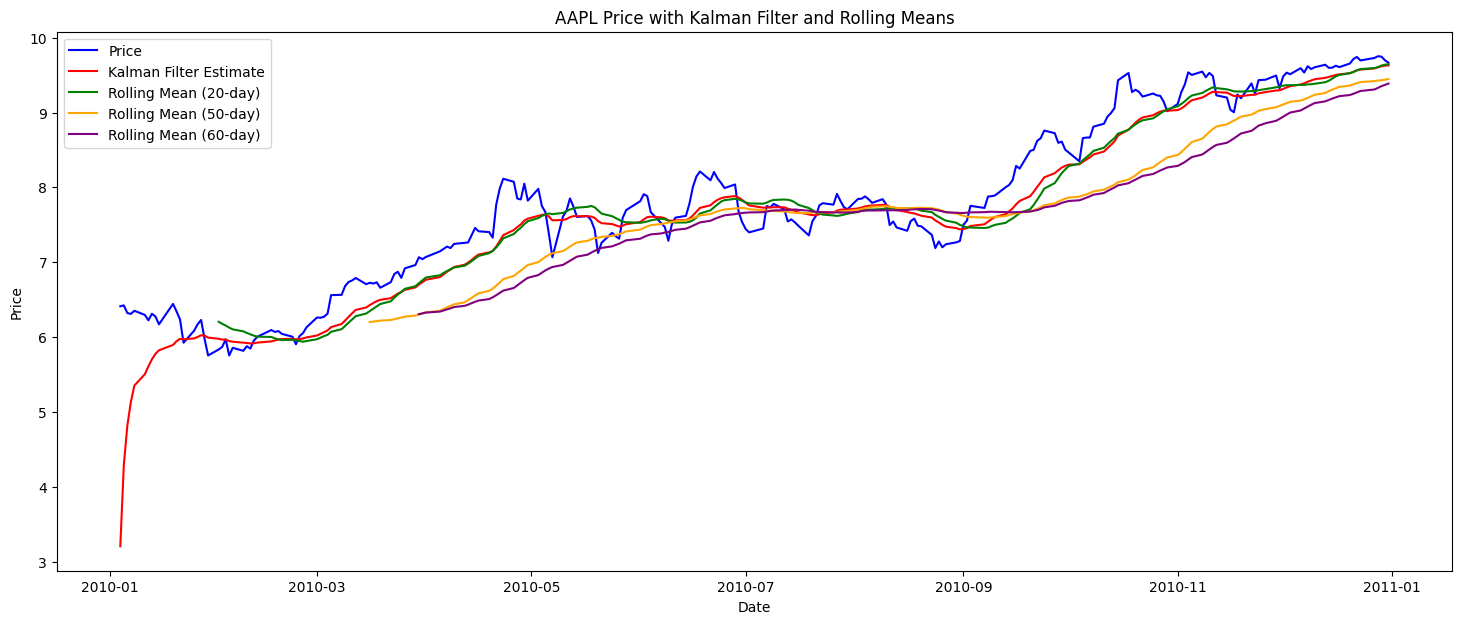

In [8]:
start_date = "2010-01-01"
end_date = "2011-01-01"
ticker = "AAPL"

# Get the price data for Apple from Yahoo Finance
prices = yf.download(ticker, start=start_date, end=end_date)["Close"]

# Construct the Kalman Filter
kf = KalmanFilter(
  transition_matrices=[1],
  observation_matrices=[1],
  initial_state_mean=0,
  initial_state_covariance=1,
  observation_covariance=1,
  transition_covariance=0.01
)

# use the observed values of the price to get a rolling mean
state_means, state_covariances = kf.filter(prices.values)

# Compute the rolling means with different window sizes
rolling_mean_20 = prices.rolling(window=20).mean()
rolling_mean_50 = prices.rolling(window=50).mean()
rolling_mean_60 = prices.rolling(window=60).mean()

# Plot the price and the rolling means, along with the Kalman Filter estimate
plt.figure(figsize=(18, 7))
plt.plot(prices.index, prices.values, label="Price", color="blue")
plt.plot(prices.index, state_means.flatten(), label="Kalman Filter Estimate", color="red")
plt.plot(prices.index, rolling_mean_20, label="Rolling Mean (20-day)", color="green")
plt.plot(prices.index, rolling_mean_50, label="Rolling Mean (50-day)", color="orange")
plt.plot(prices.index, rolling_mean_60, label="Rolling Mean (60-day)", color="purple")
plt.title(f"{ticker} Price with Kalman Filter and Rolling Means")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

**Observations from the graph:**

- The Kalman filter estimate (red) adapts **quickly** at the beginning (correcting from a poor initial guess near ~3–4) and then tracks the price path quite closely with relatively **low lag**.
- It responds to short-term movements better than the longer-window averages while still providing meaningful smoothing.
- The 20-day rolling mean (green) is fairly close to the Kalman filter but shows more choppiness.
- The 50-day and especially 60-day rolling means (orange and purple) are noticeably **smoother** but **lag** significantly behind turning points and miss shorter-term trends (e.g., they stay lower during the mid-2010 recovery and rise more slowly toward the end of 2010).

**Takeaway:**  
The Kalman filter achieves a good balance between responsiveness and smoothness **without** requiring us to cherry-pick a window length — making it a more robust and defensible choice for rolling parameter estimation in financial time series.

#### Advantages of the Kalman Filter over Traditional Moving Averages

The key advantage of using a **Kalman filter** for estimating rolling parameters (such as a moving average, Sharpe ratio, or trend) is that **we do not need to manually select a fixed window length**.

This eliminates one major source of overfitting: the arbitrary choice of lookback period (e.g., 20 days vs. 50 days can produce very different results depending on the data and market regime). By avoiding the need to pick a specific window, the Kalman filter reduces the risk of overfitting to a particular historical pattern.

However, there is **no free lunch** — the Kalman filter is not completely immune to overfitting. It can still be sensitive to:
- Initial state guess (μ₀)
- Initial uncertainty (P₀)
- Process noise variance (Q) — how much we allow the underlying state to drift
- Measurement noise variance (R) — how much we trust each new observation

Fortunately, these initialization and noise parameters are generally **easier to define objectively** or tune in a principled, statistically motivated way compared to choosing an ad-hoc rolling window size. In practice, the Kalman filter tends to be **more rigorous**, statistically grounded, and **generally superior** to a simple moving average for tracking slowly varying signals in noisy data.

### Example: Rolling Linear Regression via Kalman Filter

We apply a **Kalman filter** to dynamically estimate the parameters of a linear regression model between a stock's returns and the S&P 500 index returns. This produces **time-varying (rolling) estimates** of:
- **α** (alpha) — the intercept, representing excess return or stock-specific performance not explained by the market
- **β** (beta) — the slope coefficient, representing the stock's systematic market exposure / sensitivity

The regression model at each time *t* is:

$$
y_t \approx \alpha_t + \beta_t \, x_t + \epsilon_t
$$

where:
- $y_t$ = stock return at time *t* (dependent variable)
- $x_t$ = S&P 500 return at time *t* (independent variable / market factor)
- $\alpha_t$, $\beta_t$ = time-varying regression coefficients we want to track
- $\epsilon_t$ = residual (assumed Gaussian noise)

Instead of estimating α and β using a fixed historical window (e.g., 60 days), the Kalman filter treats α and β themselves as **unobserved states** that evolve slowly over time. This allows us to obtain smooth, adaptive estimates without choosing an arbitrary lookback period.

In [78]:
# Define a function that loads the data and generates a plot of the two asset price over a colour map
def plot_price_of_assets(ticker1, ticker2, start_date, end_date):
  # Get the price data for both tickers
  prices1 = yf.download(ticker1, start=start_date, end=end_date)["Close"]
  prices2 = yf.download(ticker2, start=start_date, end=end_date)["Close"]

  # Adjust the size of the plot
  plt.figure(figsize=(18, 9))
  cm = plt.get_cmap("viridis")
  colors = cm(np.linspace(0, 1, len(prices1)))
  
  sc = plt.scatter(prices1.values, prices2.values, c=colors, label=f"{ticker1} Price", cmap="viridis", alpha=0.7, s=10)
  cb = plt.colorbar(sc)
  cb.ax.set_yticklabels([date.strftime("%Y-%m-%d") for date in prices1.index[::len(prices1) // 5]])
  
  plt.xlabel(ticker1)
  plt.ylabel(ticker2)
  plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


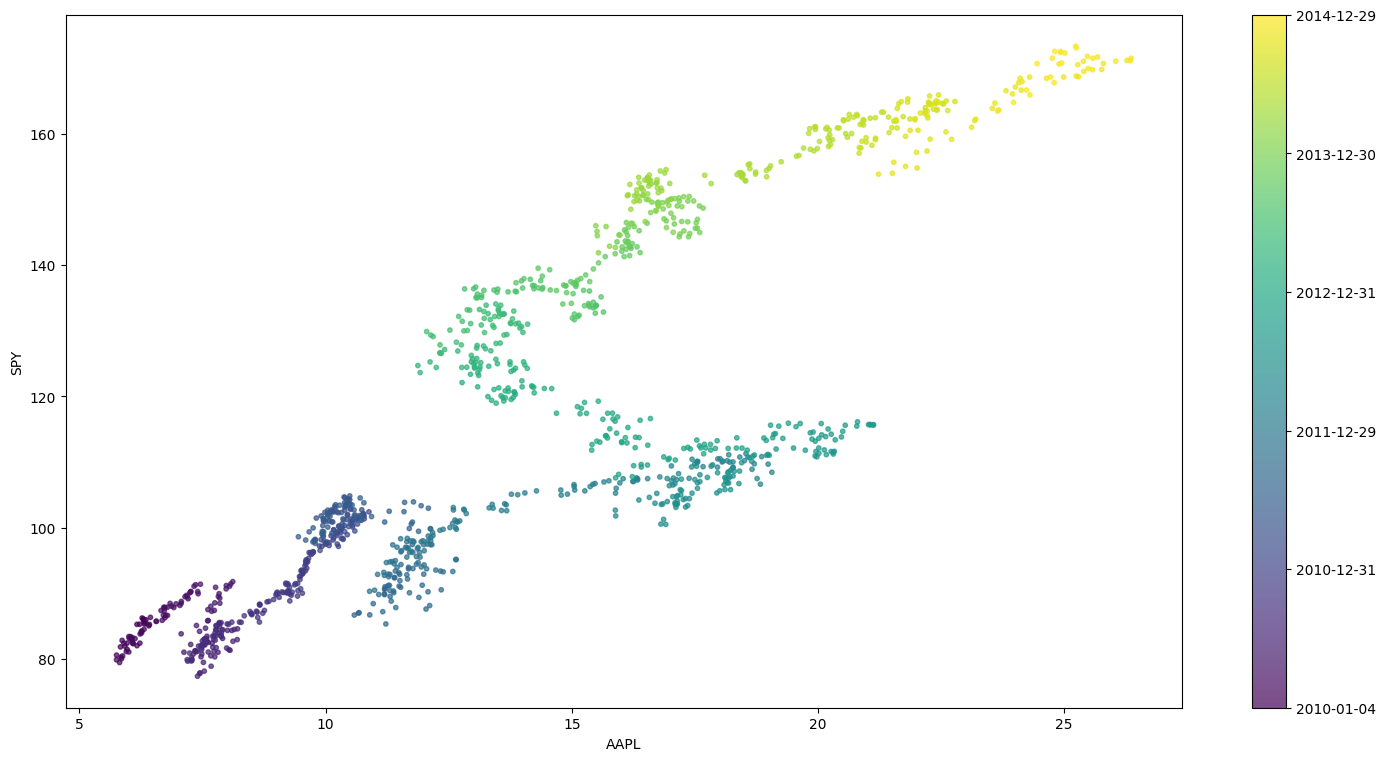

In [79]:
start_date = "2010-01-01"
end_date = "2015-01-01"
asset1 = "AAPL"
asset2 = "SPY"
plot_price_of_assets(asset1, asset2, start_date, end_date)

The **beta** (systematic risk) of our asset (e.g., AAPL) relative to the market (SPY or S&P 500) is **not constant** — it changes over time due to evolving business conditions, sector rotations, leverage changes, and market dynamics.

From the scatter plot of asset returns (y-axis) vs. SPY/market returns (x-axis), we can visually observe:
- how the relationship between the two series evolves
- clusters or patterns in how prices/returns of SPY and the asset (AAPL) move together across different time periods
- shifts in slope (β) and intercept (α) as time progresses

To dynamically estimate these time-varying **α** (alpha/excess return) and **β** (beta/market sensitivity), we use a **Kalman filter** to track the regression line as new observations arrive.

#### Kalman Filter for Rolling Linear Regression: Model Setup & Inputs

**Kalman Filter Setup for Rolling α and β**

We model the **state** of the system as the regression parameters themselves:

$$
\mathbf{z}_t = \begin{bmatrix} \alpha_t \\ \beta_t \end{bmatrix}
$$

**1. Initial State Guess**

- Initial parameter estimates (poor starting point, but filter corrects quickly):

$$
\hat{\mathbf{z}}_{0|0} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}
$$

- Initial uncertainty (error covariance matrix) — we start with high uncertainty to reflect our lack of confidence in the initial guess:

$$
\mathbf{P}_{0|0} = \text{large diagonal matrix (e.g., } 10^6 \times \mathbf{I}_2\text{)}
$$

**2. State Transition Model (Random Walk)**

We assume the true α and β evolve slowly over time as a **random walk** with small process noise:

$$
\mathbf{z}_t = \mathbf{z}_{t-1} + \mathbf{w}_t, \quad \mathbf{w}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{Q})
$$

- Transition matrix: **F = I** (identity matrix — parameters are expected to stay roughly constant between steps)
- Process noise covariance **Q**: small diagonal matrix (e.g., diag([σ_α², σ_β²]) with very small variances)  
  → controls how much we allow α and β to drift from one period to the next  
  → smaller Q → smoother, more stable estimates; larger Q → more responsive to new data

**3. Measurement / Observation Model**

Each new observation is a pair (xₜ, yₜ), where:
- xₜ = market return (SPY/S&P 500 return at time t)
- yₜ = asset return (AAPL return at time t)

We model the observation as:

$$
y_t = \begin{bmatrix} 1 & x_t \end{bmatrix} \begin{bmatrix} \alpha_t \\ \beta_t \end{bmatrix} + \epsilon_t = \alpha_t + \beta_t x_t + \epsilon_t
$$

- Observation matrix (time-varying!): **Hₜ = [1, xₜ]**
- Measurement noise variance **R**: assumed constant (e.g., R = 2 or tuned based on data volatility)  

In [80]:
delta = 1e-3
trans_cov = delta / (1 - delta) * np.eye(2) # How much random walk we expect

prices1 = yf.download(asset1, start=start_date, end=end_date)["Close"]
prices2 = yf.download(asset2, start=start_date, end=end_date)["Close"]

prices1 = prices1.iloc[:, 0]
prices2 = prices2.iloc[:, 0]

obs_mat = np.expand_dims(np.vstack([[prices1.values], [np.ones(len(prices1))]]).T, axis=1)

kf = KalmanFilter(
  n_dim_obs=1,
  n_dim_state=2, # Dim is 2 because we are estimating both the slope and the intercept (ie. alpha and beta)
  initial_state_mean=[0, 0],
  initial_state_covariance=np.ones((2, 2)),
  transition_matrices=np.eye(2),
  transition_covariance=trans_cov,
  observation_matrices=obs_mat,
  observation_covariance=2.0
)

# Use the observations of our dependent variable (prices2) to get a rolling estimate of the slope and intercept
state_means, state_covariances = kf.filter(prices2.values)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Now, we can plot the means - i.e our best estimates of α and β over time

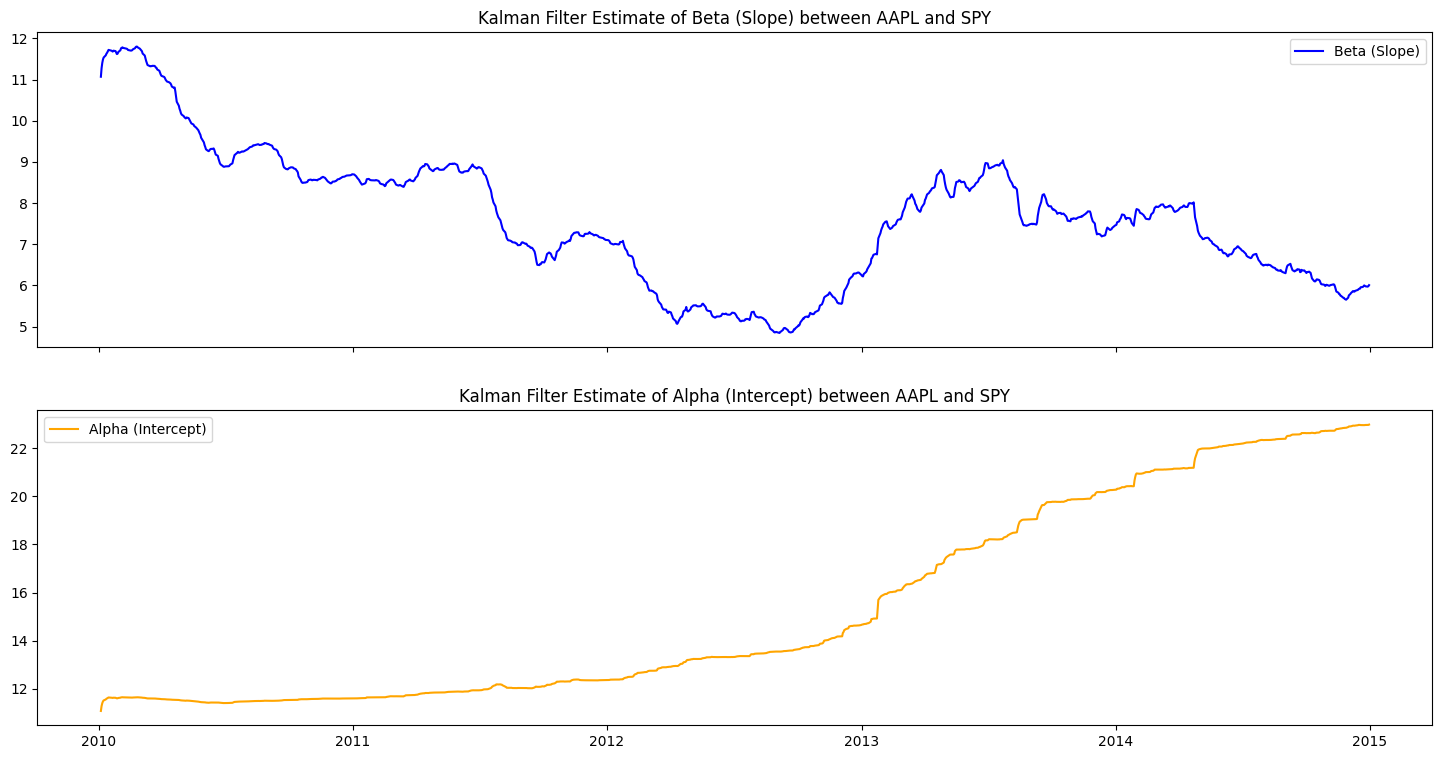

In [81]:
_, axarr = plt.subplots(2, sharex=True, figsize=(18, 9))
axarr[0].plot(prices1.index, state_means[:, 0], label="Beta (Slope)", color="blue")
axarr[0].set_title(f"Kalman Filter Estimate of Beta (Slope) between {asset1} and {asset2}")
axarr[0].legend()
axarr[1].plot(prices1.index, state_means[:, 1], label="Alpha (Intercept)", color="orange")
axarr[1].set_title(f"Kalman Filter Estimate of Alpha (Intercept) between {asset1} and {asset2}")
axarr[1].legend()
plt.show()

From the above charts, we see that α and β vary over time when we estimate them using the Kalman filters. Let us visualise this over a regression plot with the scattered prices of our assets below

In [122]:
# Define a function that loads the data and generates a plot of the two asset prices and Kalman Filter estimates of the (new) slope and intercept
def plot_price_with_kalman_regression_estimates(ticker1, ticker2, start_date, end_date):
  prices = yf.download([ticker1, ticker2], start=start_date, end=end_date)["Close"].dropna()
  prices1 = prices[ticker1]
  prices2 = prices[ticker2]  
  
  # Kalman Filter to get rolling estimates — now regressing prices1 on prices2
  delta = 1e-3
  trans_cov = delta / (1 - delta) * np.eye(2)  # How much random walk we expect

  # Observation matrix: i.e we predict prices1 ≈ β * prices2 + α
  obs_mat = np.expand_dims(np.vstack([prices2.values, np.ones(len(prices2))]).T, axis=1)

  kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2, # Still estimating intercept (α) and slope (β)
    initial_state_mean=[0, 0],
    initial_state_covariance=np.ones((2, 2)) * 1e3,  # often helpful to inflate initial uncertainty
    transition_matrices=np.eye(2),
    transition_covariance=trans_cov,
    observation_matrices=obs_mat,
    observation_covariance=2.0
  )
    
  # Filter using the new dependent variable (prices1)
  state_means, state_covariances = kf.filter(prices1.values)
  
  # Plot with swapped axes
  plt.figure(figsize=(18, 9))
  cm = plt.get_cmap("viridis")
  colors = cm(np.linspace(0, 1, len(prices1)))
  
  # Scatter: x = prices2 (ticker2), y = prices1 (ticker1), colored by time
  sc = plt.scatter(prices2.values, prices1.values, c=np.arange(len(prices1)), cmap="viridis", alpha=0.7, s=10)
  cb = plt.colorbar(sc)
  cb.ax.set_yticklabels([date.strftime("%Y-%m-%d") for date in prices1.index[::len(prices1) // 5]])
  
  # Range for plotting regression lines (now along new x = prices2)
  x_vals = np.array([prices2.min(), prices2.max()])

  # Plot every 10th Kalman filter regression line
  for i in range(0, len(prices1), 10):
    slope = state_means[i, 0] # now β = Δticker1 / Δticker2
    intercept = state_means[i, 1]
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color=colors[i], alpha=0.15)

  # OLS regression — now fitting prices1 ~ prices2
  ols_slope, ols_intercept = np.polyfit(prices2.values, prices1.values, 1)
  ols_y_vals = ols_slope * x_vals + ols_intercept
  plt.plot(x_vals, ols_y_vals, color="black", linestyle="--", label="OLS")

  # Adjust limits slightly beyond data range
  plt.xlim(prices2.min() * 0.95, prices2.max() * 1.05)
  plt.ylim(prices1.min() * 0.95, prices1.max() * 1.05)
  
  plt.title(f"{ticker1} vs {ticker2} (axes swapped) with Kalman Filter Regression Estimates")
  plt.xlabel(ticker2)
  plt.ylabel(ticker1)  
  plt.legend()
  plt.show()

[*********************100%***********************]  2 of 2 completed


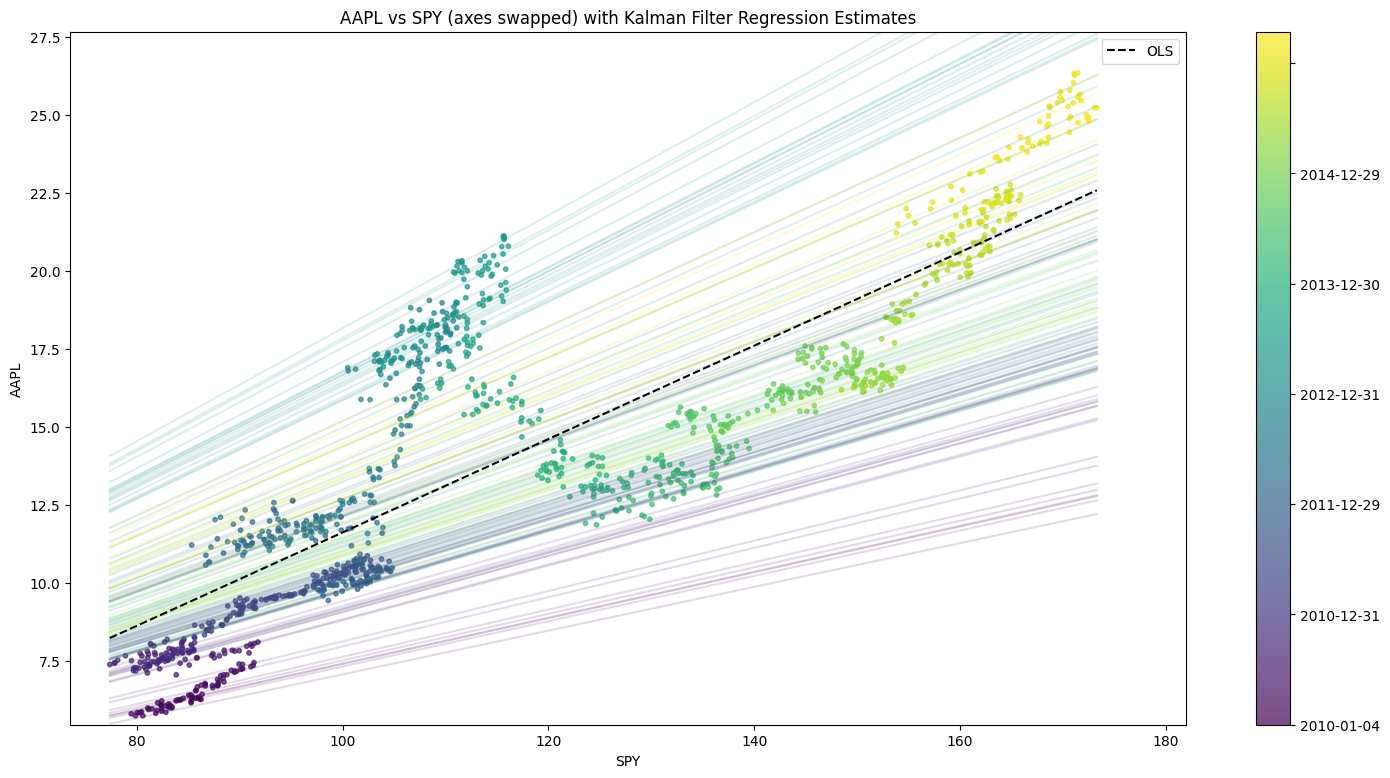

In [123]:
plot_price_with_kalman_regression_estimates(asset1, asset2, start_date, end_date)

Remarks:

---

As we can see, the Kalman filter regression addresses these issues by treating α and β as unobserved evolving states that follow a random walk (small process noise). It recursively updates estimates with each new daily observation, naturally:Producing time-varying, adaptive αₜ and βₜ that respond to recent data while remaining smooth (controlled by process/measurement noise parameters). Avoiding the need to choose an arbitrary rolling window (e.g., last 60/252 days) — which introduces lookback bias and parameter instability.

Providing a more real-time-relevant picture of market exposure (the fan of lines shows how the fitted relationship shifted over time). Offering a statistically principled way to track uncertainty (via the filter's covariance matrix Pₜ), though not shown in this plot.

In short, the graph illustrates that the AAPL–SPY relationship evolved noticeably from 2010 to 2014 — something a single OLS line completely misses. The Kalman filter captures this dynamics with a family of evolving regression lines, making it far superior for applications requiring up-to-date, regime-aware estimates of beta (e.g., risk management, dynamic asset allocation, or factor-based performance analysis) compared to a static full-sample OLS fit.

We can adjust the code above to illustrate the concept using returns instead of price data

In [128]:
# Define a function that loads the data and generates a plot of the two asset returns over a colour map, along with the Kalman Filter estimates of the slope and intercept
def plot_returns_with_kalman_regression_estimates(ticker1, ticker2, start_date, end_date):
  returns = yf.download([ticker1, ticker2], start=start_date, end=end_date)["Close"].dropna().pct_change().dropna()
  returns1 = returns[ticker1]
  returns2 = returns[ticker2]

  delta = 1e-3
  trans_cov = delta / (1 - delta) * np.eye(2) # How much random walk we expect

  obs_mat = np.expand_dims(np.vstack([[returns1.values], [np.ones(len(returns1))]]).T, axis=1)

  kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2, # Dim is 2 because we are estimating both the slope and the intercept (ie. alpha and beta)
    initial_state_mean=[0, 0],
    initial_state_covariance=np.ones((2, 2)),
    transition_matrices=np.eye(2),
    transition_covariance=trans_cov,
    observation_matrices=obs_mat,
    observation_covariance=0.01 # Different from the price version
  )
  
  # Use the observations of our dependent variable (returns2) to get a rolling estimate of the slope and intercept
  state_means, state_covariances = kf.filter(returns2.values)

  # Plot with swapped axes
  plt.figure(figsize=(18, 9))
  cm = plt.get_cmap("viridis")
  colors = cm(np.linspace(0, 1, len(returns1)))
  
  # Scatter: x = returns2 (ticker2), y = returns1 (ticker1), colored by time
  sc = plt.scatter(returns2.values, returns1.values, c=np.arange(len(returns1)), cmap="viridis", alpha=0.7, s=10)
  
  cb = plt.colorbar(sc)
  cb.ax.set_yticklabels([date.strftime("%Y-%m-%d") for date in returns1.index[::len(returns1) // 5]])
  
  # Range for regression lines (along new x = returns2)
  x_vals = np.array([returns2.min(), returns2.max()])

  # Plot every 10th Kalman filter regression line
  for i in range(0, len(returns1), 10):
    slope = state_means[i, 0]   # now β = Δticker1_return / Δticker2_return
    intercept = state_means[i, 1]
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color=colors[i], alpha=0.15)

  # OLS regression — now fitting returns1 ~ returns2
  ols_slope, ols_intercept = np.polyfit(returns2.values, returns1.values, 1)
  ols_y_vals = ols_slope * x_vals + ols_intercept
  plt.plot(x_vals, ols_y_vals, color="black", linestyle="--", label="OLS")

  # Adjust limits slightly beyond data range (returns can be negative)
  plt.xlim(returns2.min() * 1.1 if returns2.min() < 0 else returns2.min() * 0.9, returns2.max() * 1.1)
  plt.ylim(returns1.min() * 1.1 if returns1.min() < 0 else returns1.min() * 0.9, returns1.max() * 1.1)
  
  plt.title(f"{ticker1} Returns vs {ticker2} Returns (axes swapped) — Kalman Filter Regression")
  plt.xlabel(f"{ticker2} Daily Returns")
  plt.ylabel(f"{ticker1} Daily Returns")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

[*********************100%***********************]  2 of 2 completed


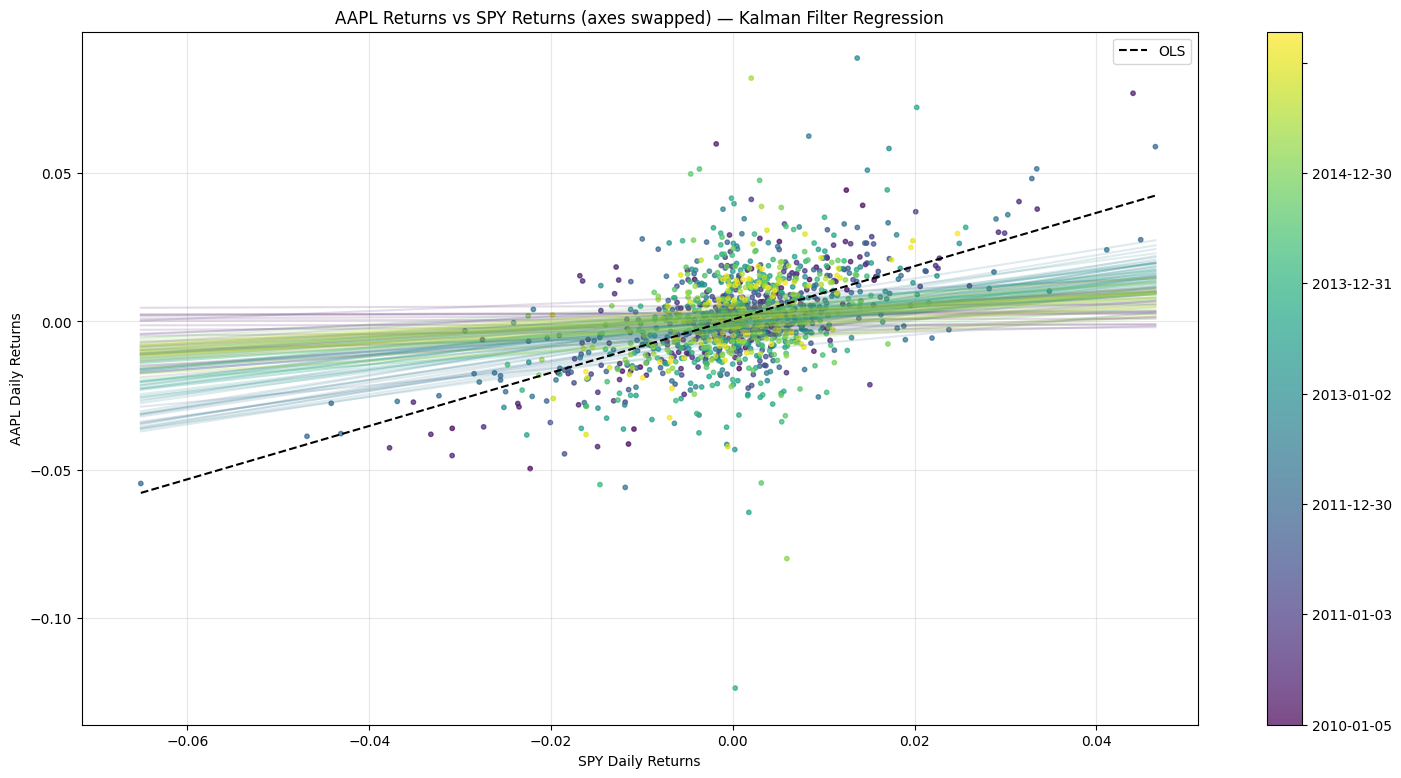

In [129]:
plot_returns_with_kalman_regression_estimates(asset1, asset2, start_date, end_date)

Remarks:

---
As seen above,
- The black dashed line (labeled “OLS”): This is the ordinary least-squares regression line fitted to all the data at once. It represents the static, average linear relationship across the entire 5-year period. Its positive slope is the classic “beta” estimate: on average, AAPL moved roughly 1.0–1.1× as much as the market (a typical tech-stock beta). The line roughly passes near the origin, meaning little average alpha (outperformance independent of the market).
- The colored lines (the “Kalman Filter Regression”): These are time-varying regression lines produced by a Kalman filter. Unlike OLS, which gives one fixed line, the Kalman filter treats the slope (beta) and intercept as states that can evolve gradually with each new day’s data. It updates its best estimate of the relationship in real time, producing a new regression line for each period. All these lines are plotted together on the same chart, colored by the date they correspond to.

The fan/spread of colored lines is the most important feature: it shows the relationship is not constant. The lines pivot roughly around the center (near 0,0) but fan out at the extremes, revealing that both the slope (beta) and intercept have drifted over time. It demonstrates that AAPL’s daily returns did not have a fixed relationship with the market. The Kalman filter lets us watch that relationship evolve in real time across the 2010–2014 window: beta started relatively high, stabilized in the middle years, and showed signs of increasing again by late 2014. This is exactly why dynamic models like Kalman filtering are used in finance—they reveal changes that a single OLS line hides.

**A more detailed observation of the chart:**

**1. The relationship is dynamic, not fixed**

OLS tells you only the long-run average beta. The Kalman lines show that beta fluctuated meaningfully from 2010 to 2014. In some periods AAPL amplified market moves more (steeper lines); in others it moved more independently (flatter lines). This is typical for a high-growth tech stock—company-specific news, product launches (e.g., iPhone cycles), or changing market regimes altered how closely AAPL tracked the broad market.


**2, Chronological evolution visible via color**  

- Early period (purple/dark blue, ~2010–early 2012): Lines are generally lower on the left side of the chart (when SPY returns are negative). This corresponds to relatively higher beta in the earliest years—AAPL tended to fall more than the market on down days.  
- Middle period (green/teal, ~2012–2013): Lines cluster tighter around the OLS line. The relationship was closer to the long-run average.  
- Later period (yellow/lime, ~2014): Lines shift upward on the right side (when SPY returns are positive). AAPL began to outperform the market more on up days, consistent with Apple’s strong growth phase in 2014. The overall fan shows beta trended slightly higher toward the end of the sample.

**3. Practical implications for returns** 

- Risk management: A static beta would have understated or overstated AAPL’s market exposure at different times. The Kalman filter gives a “live” beta you could have used for hedging or portfolio construction day-by-day.  
- Volatility clustering: Notice how the scatter points (and lines) spread wider on big-move days. The time-varying lines adapt to these regimes, showing periods when AAPL was more (or less) sensitive to market shocks.  
- No strong alpha drift: Most lines still pass close to the origin, so AAPL’s outperformance was mostly explained by its (changing) market beta rather than consistent alpha.